In [1]:
from experiment_modules import *
from numpy.testing import assert_array_equal

import matplotlib.pyplot as plt
import seaborn as sns

from copy import deepcopy
from rich.progress import track

Using backend: cpu

Available hardware:

TFRT_CPU_0

In [2]:
rng = jax.random.PRNGKey(0)
generator = Generator(50)

In [3]:
def calculate_entropy_from_model(state, generator=generator):
    """
    Compute the entropy of a model on some data.
    """
    ntk_fn = get_ntk_function(state.apply_fn, None)

    ntk_matrix = ntk_fn(
                    generator.train_ds["inputs"],
                    generator.train_ds["inputs"],
                    {"params": state.params}
                )

    return compute_entropy(ntk_matrix)    

In [4]:
one_layer = build_network(
    width=3, depth=1, w_std=1.0, b_std=1., use_bias=False
)()
one_state = create_train_state(one_layer, rng, 1e-3)
entropy = calculate_entropy_from_model(one_state)

In [5]:
entropy

0.19644648

# No bias

In [103]:
np.linspace(2000, 2100, 100, dtype=int)

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032,
       2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043,
       2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
       2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065,
       2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076,
       2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087,
       2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098,
       2100])

In [ ]:
widths = list(entropy.keys())
weights = [0.1, 1.0]

# entropy = {}

for width in widths:
#     entropy[width] = {}
    for weight in weights:
        network = build_network(
            width=width, 
            depth=1, 
            w_std=weight, 
            b_std=1., 
            use_bias=False
        )()
        state = create_train_state(network, rng, 1e-3)
        entropy[width][weight] = calculate_entropy_from_model(state)

In [ ]:
for weight_init in weights:
    plt.plot(
        list(entropy.keys()), [item[weight_init] for item in entropy.values()], ".", label=weight_init
    )

plt.legend(title="Initialization")
plt.xscale("log")
plt.xlabel("Hidden Layer Dimension")
plt.ylabel("NTK Entropy")
# plt.xlim(500, 10000)
# plt.savefig("linear-addition-no-log.png", dpi=400)
plt.show()

In [ ]:
np.save("single-layer-entropy.npy", entropy)

In [112]:
entropy

{1: {0.01: 0.19644648},
 10: {0.01: 0.19644892},
 100: {0.01: 0.19645593},
 1000: {0.01: 0.19648132},
 10000: {0.01: 0.19646817},
 100000: {0.01: 0.19649042},
 500000: {0.01: 0.19664235},
 600000: {0.01: 0.19667917},
 200000: {0.01: 0.19652604},
 300000: {0.01: 0.1965672},
 400000: {0.01: 0.1966063},
 5: {0.01: 0.19644688},
 50: {0.01: 0.19645908},
 500: {0.01: 0.19646129},
 5000: {0.01: 0.19646704},
 2: {0.01: 0.19644648},
 3: {0.01: 0.19644657},
 4: {0.01: 0.1964466},
 6: {0.01: 0.19644718},
 7: {0.01: 0.1964475},
 8: {0.01: 0.19644785},
 9: {0.01: 0.19644833},
 20: {0.01: 0.19645444},
 30: {0.01: 0.19646087},
 40: {0.01: 0.19645414},
 60: {0.01: 0.1964547},
 70: {0.01: 0.19645569},
 80: {0.01: 0.1964545},
 90: {0.01: 0.19645473},
 200: {0.01: 0.1964558},
 300: {0.01: 0.19645575},
 400: {0.01: 0.19645703},
 600: {0.01: 0.19646545},
 700: {0.01: 0.19646987},
 800: {0.01: 0.19647405},
 900: {0.01: 0.19647698},
 2000: {0.01: 0.19648218},
 3000: {0.01: 0.19648227},
 4000: {0.01: 0.196482

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


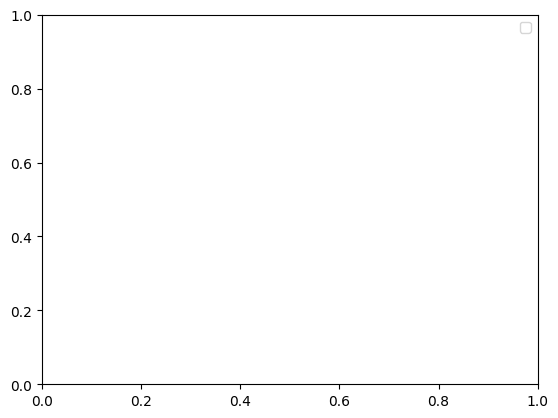

In [71]:
plot_array = np.array([
    [item[i] for item in entropy.values()] for i in weights
])
diffs = np.diff(plot_array, axis=0)

for i, item in enumerate(diffs):
    plt.plot(item, ".", label=fr"{i} $\rightarrow$ {i + 1}")

plt.legend()
plt.show()